# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [5]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [6]:
instrument_id = '511090'
trade_ymd = '20260319'
train_preset = 'volatility_12d'  # 可选: 'recent_6d', 'volatility_8d', 'volatility_12d', 'volatility_16d'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': f'delta_v1_adaptive_{train_preset}',
    'stride': 1,

    'short_window': 300,
    'long_window': 600,
    'y_window': 600,

    'open_threshold': 3,  
    'open_confidence': 0,  

    'standard_num': 1000,

    'atr_multiplier': 4,
    'vol_window': 600,
    
    'k_up': 3,
    'k_down': 3,
    "stop_tighten_start": 3000,
    'stop_tighten_step' : 6000,
    'stop_tighten_factor': 1,
    'stop_tighten_floor': 0.75,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [52]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

# 旧训练方式保留注释，不再直接使用：
# train_dates, valid_dates, test_dates = split_dates(trade_dates,45,15,17)
# train_dates, valid_dates, test_dates = split_dates_by_range(
#     trade_dates,
#     train_start="20250901",
#     train_end="20260228",
#     valid_start="20251201",
#     valid_end="20251201",
#     test_start="20260301",
#     test_end="20261231",
# )
# 上面这种写法容易让验证集与训练集重叠，后面也容易误把测试集当验证集。

train_candidate_dates, _, _ = split_dates_by_range(
    trade_dates,
    train_start="20250901",
    train_end="20260227",
)

_, valid_dates, _ = split_dates_by_range(
    trade_dates,
    valid_start="20260303",
    valid_end="20260311",
)

_, _, test_dates = split_dates_by_range(
    trade_dates,
    test_start="20260313",
    test_end="20260409",
)

train_dates = select_train_dates_by_preset(
    train_preset,
    train_candidate_dates,
    instrument_id=instrument_id,
)

print(f"当前训练方案: {train_preset}")
print(f"最终训练天数: {len(train_dates)}")
print("训练日期列表:", train_dates)


总交易日数量: 74
交易日范围: 20250901 ~ 20260409
训练集: 20250901 ~ 20260227 (59天)
验证集: 无
测试集: 无
训练集: 无
验证集: 20260303 ~ 20260311 (4天)
测试集: 无
训练集: 无
验证集: 无
测试集: 20260313 ~ 20260409 (11天)
当前训练方案: volatility_16d
最终训练天数: 16
训练日期列表: ['20250911', '20250915', '20250925', '20250929', '20251015', '20251027', '20251107', '20251113', '20251121', '20251125', '20251127', '20251209', '20260113', '20260127', '20260129', '20260225']


## 生成训练数据

In [53]:
# 旧方式保留注释，不再分别调用 samples_from_dates：
# X_train, y_train, feature_names = samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
# X_valid, y_valid, _ = samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
# X_test, y_test, _ = samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)

all_dates = sorted(set(train_dates) | set(valid_dates) | set(test_dates))
sample_cache = load_daily_sample_cache(
    all_dates,
    instrument_id,
    param_dict,
    create_feature,
    create_y,
)

X_train, y_train, feature_names = concat_sample_cache(sample_cache, train_dates)
X_valid, y_valid, _ = concat_sample_cache(sample_cache, valid_dates)
X_test, y_test, _ = concat_sample_cache(sample_cache, test_dates)

print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")

20250911: 产生 292 个样本
20250915: 产生 321 个样本
20250925: 产生 291 个样本
20250929: 产生 330 个样本
20251015: 产生 335 个样本
20251027: 产生 328 个样本
20251107: 产生 300 个样本
20251113: 产生 324 个样本
20251121: 产生 377 个样本
20251125: 产生 311 个样本
20251127: 产生 328 个样本
20251209: 产生 341 个样本
20260113: 产生 327 个样本
20260127: 产生 296 个样本
20260129: 产生 289 个样本
20260225: 产生 313 个样本
20260303: 产生 314 个样本
20260305: 产生 278 个样本
20260309: 产生 344 个样本
20260311: 产生 310 个样本
20260313: 产生 282 个样本
20260317: 产生 320 个样本
20260319: 产生 309 个样本
20260323: 产生 297 个样本
20260325: 产生 297 个样本
20260327: 产生 306 个样本
20260331: 产生 278 个样本
20260401: 产生 304 个样本
20260403: 产生 325 个样本
20260407: 产生 301 个样本
20260409: 产生 331 个样本
训练集样本: X=(5103, 12), y=(5103,)
验证集样本: X=(1246, 12), y=(1246,)
测试集样本: X=(3350, 12), y=(3350,)


In [54]:
# 不再单独生成验证集样本，上一格已经通过 sample_cache 一次性完成。
pd.Series(y_train).value_counts().rename('train_label_count')

0    3411
1    1692
Name: train_label_count, dtype: int64

In [55]:
pd.Series(y_valid).value_counts().rename('valid_label_count')

0    817
1    429
Name: valid_label_count, dtype: int64

In [56]:
# 旧代码如下，已禁用：
# X_valid = X_test
# y_valid = y_test
# 不要再把测试集当验证集用，这会污染阈值优化和模型选择。

pd.Series(y_test).value_counts().rename('test_label_count')

0    2270
1    1080
Name: test_label_count, dtype: int64

## 训练模型

In [57]:
print(f"开始训练，方案: {train_preset}")
model = train_model(X_train, y_train, X_valid, y_valid, param_dict , feature_names)

开始训练，方案: volatility_16d
训练 xgboost 模型...
[0]	validation_0-logloss:0.69232


[100]	validation_0-logloss:0.65234
[200]	validation_0-logloss:0.65331
[300]	validation_0-logloss:0.66541
[400]	validation_0-logloss:0.67279
[500]	validation_0-logloss:0.68041
[600]	validation_0-logloss:0.68542
[700]	validation_0-logloss:0.69247
[799]	validation_0-logloss:0.69485
阈值优化完成: Best Threshold=0.6401, F0.5=0.4746

特征重要性（前10个）:
volatility    0.199936
alpha_07      0.083762
WAMP          0.083295
alpha_04      0.081855
alpha_06      0.080027
alpha_03      0.075021
alpha_02      0.069452
spread        0.069375
num_trades    0.068134
volume        0.064765
dtype: float32

XGBoost特征重要性详情:

Gain重要性排名:
       feature       gain
1   volatility  33.575710
11    alpha_07  14.066388
3         WAMP  13.987929
8     alpha_04  13.746172
10    alpha_06  13.439225
7     alpha_03  12.598481
6     alpha_02  11.663257
2       spread  11.650396
0   num_trades  11.441863
4       volume  10.876121
9     alpha_05  10.527751
5     alpha_01  10.359398

Weight重要性排名:
       feature  weight
1   volatility

In [58]:
# 保存模型
model_path = f"/home/jovyan/work/model/delta_{instrument_id}_{train_preset}.pkl"
import joblib
joblib.dump(model, model_path)
print(f"模型已保存到: {model_path}")

模型已保存到: /home/jovyan/work/model/delta_518880_volatility_16d.pkl


## 测试模型

测试集准确率: 0.6788

分类报告:
              precision    recall  f1-score   support

           0       0.70      0.91      0.79      2270
           1       0.51      0.19      0.27      1080

    accuracy                           0.68      3350
   macro avg       0.60      0.55      0.53      3350
weighted avg       0.64      0.68      0.63      3350


PR曲线AUC: 0.4403
平均精度 (AP): 0.4412

预测概率统计:
  均值: 0.3537
  标准差: 0.2123
  最小值: 0.0345
  25%分位数: 0.1700
  中位数: 0.3188
  75%分位数: 0.5224
  最大值: 0.9168

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.3187, 标准差=0.2035
  标签1 (正类): 均值=0.4272, 标准差=0.2114


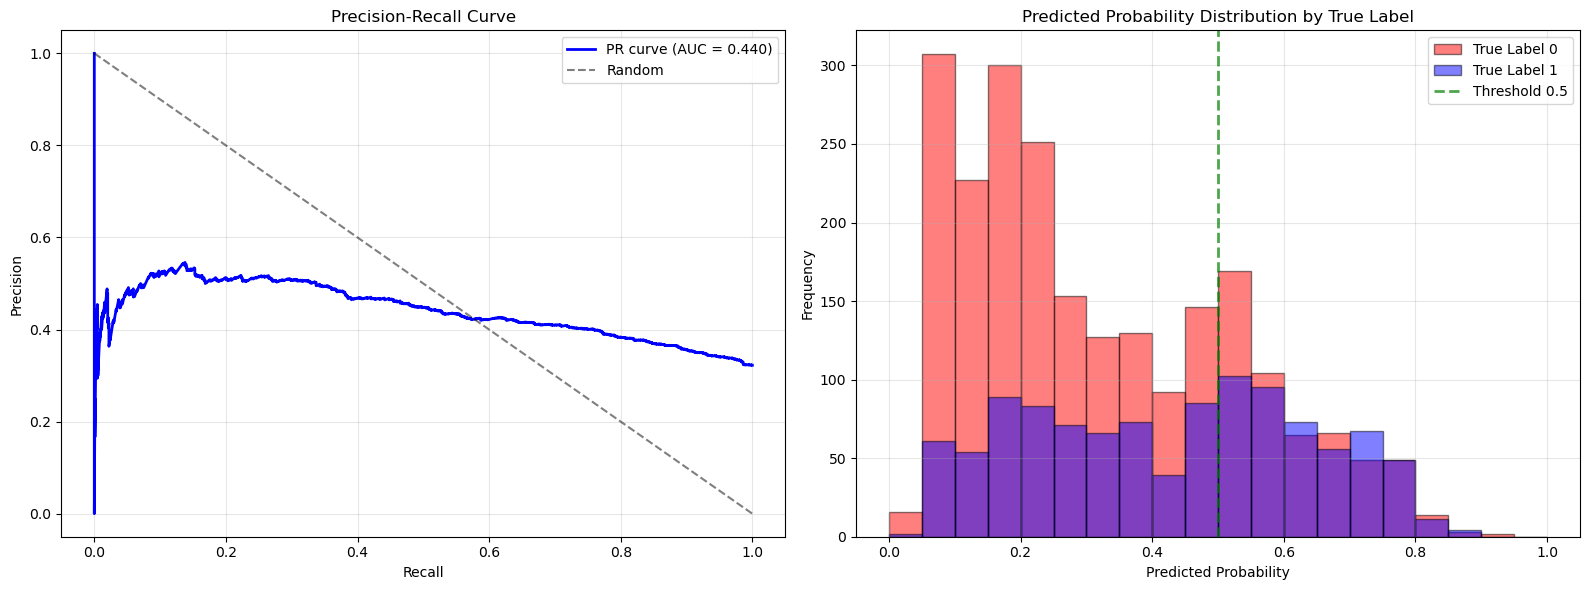

In [59]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

## 创建策略实例

In [1]:
model_path = f"/home/jovyan/work/model/delta_{instrument_id}_{train_preset}.pkl"
strategy = StrategyDemo(model_path, param_dict)
print(f"策略已创建: {strategy.name}")

NameError: name 'instrument_id' is not defined

## 使用backtesting工具进行回测

In [ ]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20250101",
    end_ymd="20261231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4,
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)
print(summary)

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 74 个有数据的交易日
-> 过滤后剩余 74 个有数据的交易日
-> 过滤掉 656 个无数据日期: ['20250101', '20250102', '20250103', '20250104', '20250105', '20250106', '20250107', '20250108', '20250109', '20250110']...
-> 回测标的: 511090 (20250101 - 20261231)
-> 任务分配: 共 74 天，使用 4 个核心并行计算...


## 延迟回测结果

In [ ]:
from delay_stability_test import batch_delay_stability_test
batch_delay_stability_test(
    instrument_id,
    "20251201",
    "20251231",
    StrategyDemo,
    model_path,
    param_dict,
    [0,1,2,4,8,16,32,64,128,256,512,1024],
    
)

## 保存回测结果

In [499]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果

result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/backtest_result/511130_delta_v1_adaptive_20260424_092723
回测结果已保存到: /home/jovyan/work/tactics_demo/backtest_result/511130_delta_v1_adaptive_20260424_092723
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [362]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260413", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("511520", "20260420", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹
已删除: /home/jovyan/work/tactics_demo/backtest_result/511520_delta_v1_adaptive_20260420_062243

总共删除了 1 个文件夹


## 单日回测观察

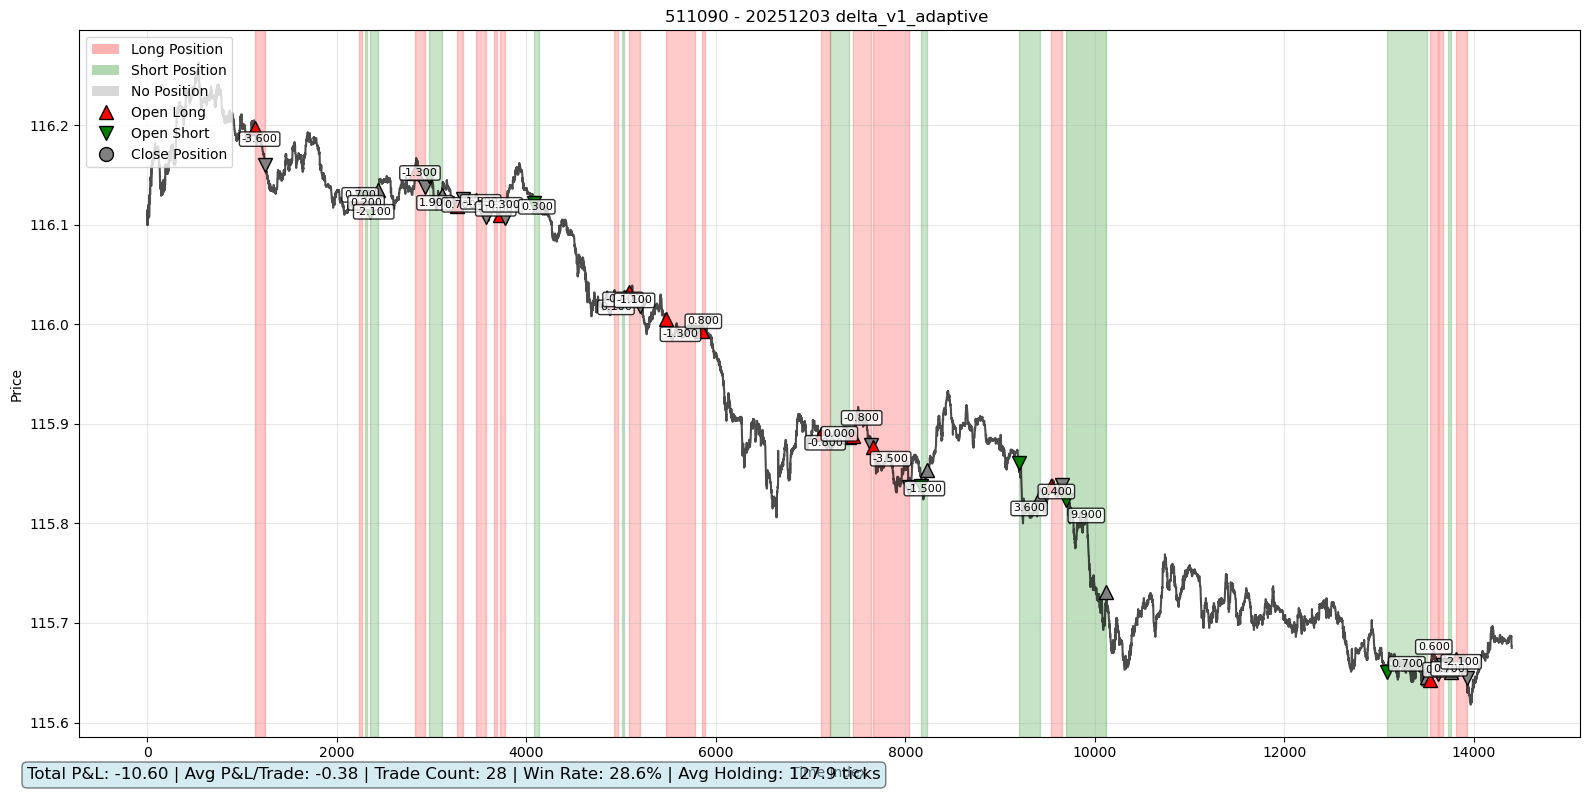

In [349]:
from single_day_backtest import single_day_backtest,plot_delta_history
strategy = StrategyDemo(model_path, param_dict)
hh = single_day_backtest(instrument_id,'20251203',StrategyDemo,model_path,param_dict,official = False)

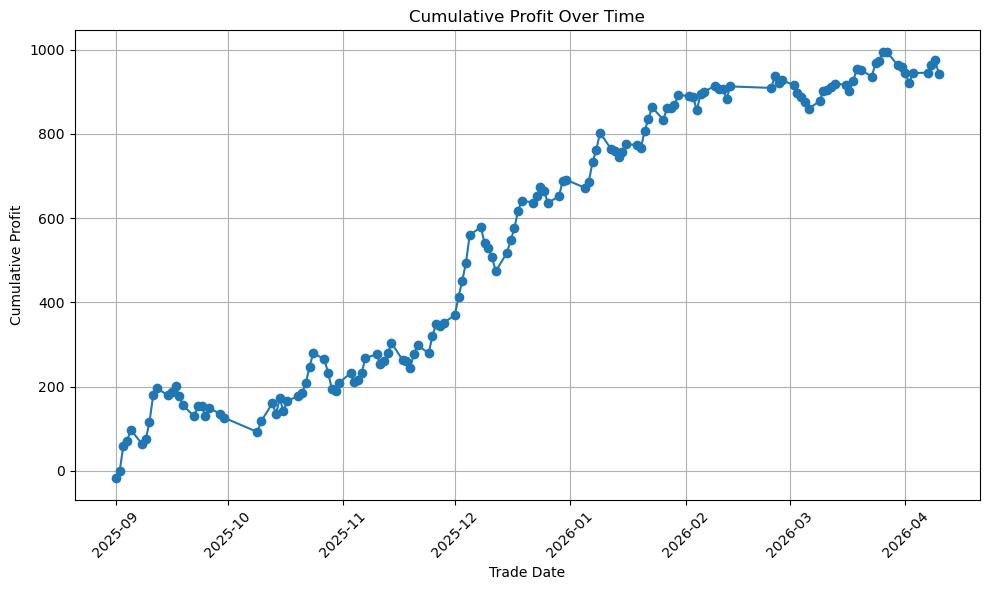

In [20]:
summary = pd.read_csv('/home/jovyan/work/live_trading/511090_20260421_oyyb_01.csv')
# plot cumulative profits

summary['cumulative_profit'] = summary['profits'].cumsum()
summary['trade_ymd'] = pd.to_datetime(summary['trade_ymd'], format='%Y%m%d')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(summary['trade_ymd'], summary['cumulative_profit'], marker='o')
plt.title('Cumulative Profit Over Time')
plt.xlabel('Trade Date')
plt.ylabel('Cumulative Profit')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
